# Day 3 - Week 5: Dimensionality Reduction with PCA

### Importing

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

### Step 1: Scale a high-dimensional provided dataset with StandardScaler.

In [5]:
df = pd.read_csv('data/cardio_patients_raw.csv')
pca_features = [
    'age',
    'resting_bp',
    'cholesterol',
    'bmi',
    'fasting_blood_sugar',
    'max_heart_rate'
]

X = df[pca_features]
pca_preprocess = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

X_scaled = pca_preprocess.fit_transform(X)
print("Original shape:", X.shape)
print("Scaled shape:", X_scaled.shape)

Original shape: (1215, 6)
Scaled shape: (1215, 6)


## Step 1: Markdown
The selected numerical features were first processed using median imputation
to handle missing values, followed by StandardScaler.

Scaling is important before PCA because PCA is based on variance.
Without scaling, features with larger numerical ranges, such as cholesterol
or blood pressure, could dominate the principal components simply because
of their scale rather than their actual importance.

### Step 2: Fit PCA and plot the cumulative explained variance against the number of components.


In [7]:
pca_full = PCA()

X_pca_full = pca_full.fit_transform(X_scaled)
print("Explained variance ratio:")

for i, variance in enumerate(pca_full.explained_variance_ratio_, start=1):
    print(f"PC{i}: {variance:.4f} ({variance * 100:.2f}%)")

Explained variance ratio:
PC1: 0.3337 (33.37%)
PC2: 0.1783 (17.83%)
PC3: 0.1571 (15.71%)
PC4: 0.1422 (14.22%)
PC5: 0.1296 (12.96%)
PC6: 0.0590 (5.90%)


In [8]:
cumulative_variance = np.cumsum(
    pca_full.explained_variance_ratio_
)

print("Cumulative explained variance:")

for i, variance in enumerate(cumulative_variance, start=1):
    print(f"{i} components: {variance * 100:.2f}%")

Cumulative explained variance:
1 components: 33.37%
2 components: 51.20%
3 components: 66.92%
4 components: 81.13%
5 components: 94.10%
6 components: 100.00%


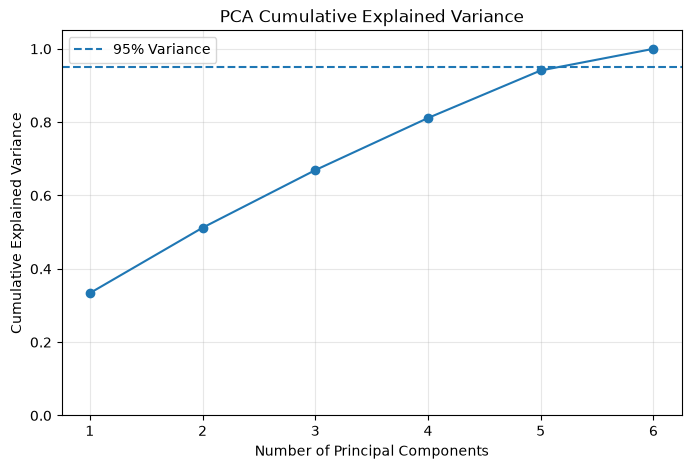

In [9]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker='o'
)

plt.axhline(
    y=0.95,
    linestyle='--',
    label='95% Variance'
)

plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Cumulative Explained Variance')

plt.xticks(
    range(1, len(cumulative_variance) + 1)
)

plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.legend()

plt.show()

### Step 2: Markdown

PCA was first fitted using all six available principal components in order
to measure how much variance each component explains.

The explained variance ratios were:

- PC1: **33.37%**
- PC2: **17.83%**
- PC3: **15.71%**
- PC4: **14.22%**
- PC5: **12.96%**
- PC6: **5.90%**

The cumulative explained variance was then calculated to show how much of
the total information is retained as more principal components are added.

The cumulative variance reached:

- 1 component: **33.37%**
- 2 components: **51.20%**
- 3 components: **66.92%**
- 4 components: **81.13%**
- 5 components: **94.10%**
- 6 components: **100.00%**

A cumulative explained variance plot was used to visualize this relationship.
A horizontal reference line at **95% variance** was added to help determine
how many principal components are required to preserve approximately 95%
of the information in the original dataset.

The plot shows that five components retain 94.10% of the variance, which is
slightly below the 95% target. Therefore, all six components are required
to exceed the 95% threshold.

### Step 3: Choose the number of components that retains ~95% of the variance and justify it.


In [10]:
n_components_95 = np.argmax(
    cumulative_variance >= 0.95
) + 1

print(
    f"Number of components required for 95% variance: "
    f"{n_components_95}"
)

Number of components required for 95% variance: 6


In [11]:
pca_95 = PCA(n_components=0.95)

X_pca_95 = pca_95.fit_transform(X_scaled)

print("Original number of features:", X_scaled.shape[1])
print("Number of PCA components:", pca_95.n_components_)

print(
    "Total explained variance:",
    pca_95.explained_variance_ratio_.sum()
)

Original number of features: 6
Number of PCA components: 6
Total explained variance: 1.0


## Step 3: Markdown
The cumulative explained variance analysis showed that five principal
components retain approximately 94.10% of the total variance.

However, because the target threshold was at least 95%, six components
were required to reach the threshold, retaining 100% of the variance.

Since the original dataset contains only six features, using a strict
95% threshold does not reduce the dimensionality of this dataset.

This suggests that the original features contain relatively distinct
information and that PCA cannot substantially compress them without
losing more than 5% of the total variance.

### Step 4: Reduce the data to 2 components and produce a 2D scatter plot, coloring points by a known group if available.

In [12]:
pca_2d = PCA(n_components=2)

X_pca_2d = pca_2d.fit_transform(X_scaled)

In [14]:
pc1_variance = pca_2d.explained_variance_ratio_[0] * 100
pc2_variance = pca_2d.explained_variance_ratio_[1] * 100
total_2d_variance = pca_2d.explained_variance_ratio_.sum() * 100

print(f"PC1: {pc1_variance:.2f}%")
print(f"PC2: {pc2_variance:.2f}%")
print(f"Total retained in 2D: {total_2d_variance:.2f}%")

PC1: 33.37%
PC2: 17.83%
Total retained in 2D: 51.20%


In [15]:
pca_df = pd.DataFrame(
    X_pca_2d,
    columns=['PC1', 'PC2'],
    index=df.index
)

pca_df.head()

,PC1,PC2
0,0.376138,1.700263
1,2.074892,1.346679
2,1.684669,0.503110
3,-1.392015,-0.580895
4,-1.322919,-0.884297


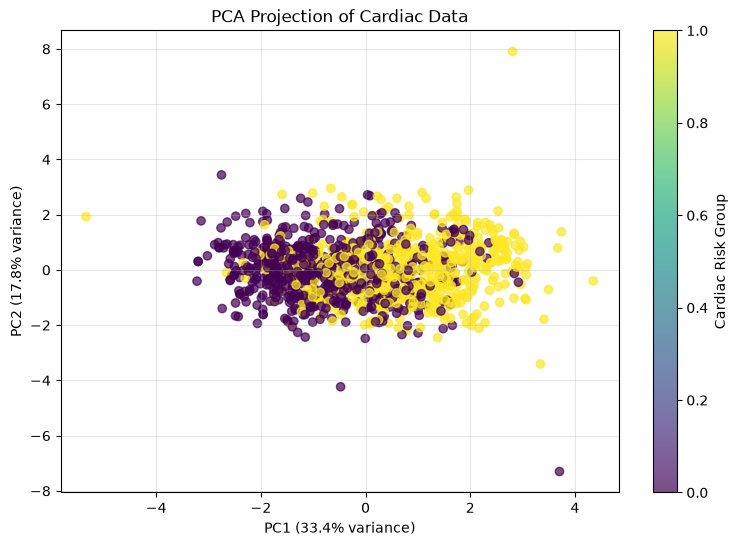

In [17]:
pca_df['cardiac_risk'] = df['cardiac_risk']
plt.figure(figsize=(9, 6))

scatter = plt.scatter(
    pca_df['PC1'],
    pca_df['PC2'],
    c=pca_df['cardiac_risk'],
    alpha=0.7
)

plt.xlabel(
    f'PC1 ({pc1_variance:.1f}% variance)'
)

plt.ylabel(
    f'PC2 ({pc2_variance:.1f}% variance)'
)

plt.title(
    'PCA Projection of Cardiac Data'
)

plt.colorbar(
    scatter,
    label='Cardiac Risk Group'
)

plt.grid(alpha=0.3)

plt.show()

### Step 4: Markdown

To visualize the dataset in two dimensions, PCA was applied again using
only two principal components.

The first principal component (PC1) explained **33.37%** of the total
variance, while the second principal component (PC2) explained **17.83%**.

Together, the first two components retained **51.20%** of the total
variance in the original dataset.

The transformed data was plotted using PC1 on the x-axis and PC2 on the
y-axis. Each point represents one observation from the original dataset.

The points were colored using the known `cardiac_risk` group to help
visually inspect whether the two groups show any separation or clustering
in the reduced two-dimensional space.

The `cardiac_risk` variable was **not included as an input feature in PCA**.
It was used only for coloring the points in the visualization.

Because the two principal components retain only 51.20% of the total
variance, the 2D plot should be treated as a simplified representation of
the original six-dimensional dataset rather than a complete representation
of all its information.

### Step 5: Document what the reduction preserved and what it cost in Markdown.

The original dataset contained 1,215 observations and 6 numerical
features.

The first principal component explained 33.37% of the total variance,
while the second explained 17.83%. Together, the first two components
retained 51.20% of the total variance.

The cumulative explained variance reached:

- 33.37% with 1 component
- 51.20% with 2 components
- 66.92% with 3 components
- 81.13% with 4 components
- 94.10% with 5 components
- 100% with all 6 components

Because five components retained only 94.10% of the variance, all six
components were required to satisfy the 95% variance threshold.

Therefore, PCA did not provide meaningful dimensionality reduction at
the strict 95% threshold for this dataset. This suggests that most of
the original features contribute distinct information and that removing
a component would result in more than 5% information loss.

For visualization, the data was reduced to two principal components.
PC1 and PC2 retained 51.20% of the total variance. This two-dimensional
representation is useful for visually inspecting patterns, clusters,
and possible separation between known groups, but it does not represent
all of the information contained in the original six-dimensional data.

### What was preserved

PCA preserved the strongest directions of variation in the dataset.
Using all six components preserved 100% of the variance, while the
two-component representation preserved 51.20%.

### What was lost

Reducing the dataset to two dimensions resulted in approximately 48.80%
of the variance being excluded from the visualization. In addition,
principal components are combinations of the original features, making
them less directly interpretable than variables such as age, BMI, or
cholesterol.